In [10]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn

### creating a model 2 * x + 1

In [11]:
## creating our data set
x=torch.linspace(0,1,40).unsqueeze(dim=1)
y=2*x + 1

In [12]:
# creating our model
class LinearModel(nn.Module):
    def __init__(self):
        super(LinearModel,self).__init__()
        self.linear=nn.Linear(1,1)
    def forward(self, x):
        return self.linear(x)

In [13]:
##Initialize the model
model = LinearModel()
loss = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


In [14]:
##training loop 
epoches =100
for epoch in range(epoches):
    y_pred=model(x)
    current_loss = loss(y_pred, y)
    optimizer.zero_grad()
    current_loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {current_loss.item()}")
for name, param in model.named_parameters():
    print(f"{name}: {param.data}")

print(model(torch.tensor([[5.0]])))  # should be ≈ 11

Epoch 0, Loss: 5.157373905181885
Epoch 20, Loss: 1.9505951404571533
Epoch 40, Loss: 0.7977050542831421
Epoch 60, Loss: 0.37989094853401184
Epoch 80, Loss: 0.22533611953258514
linear.weight: tensor([[0.6917]])
linear.bias: tensor([1.5306])
tensor([[4.9889]], grad_fn=<AddmmBackward0>)


### working this model with numpy

In [15]:
#making data set

x=np.linspace(0,1,40).reshape(-1,1)
y=2*x + 1
learning_rate=0.01
#making random parameter
w=np.random.randn(1)
b=np.random.randn(1)

#making our model
def pred_func(x):
    y_pred=w*x + b
    return y_pred
#training loop
epoches=2000
for epoch in range(epoches):
    y_pred=pred_func(x)
    loss = np.mean((y_pred - y)**2)
    grad_w = np.mean(2 * (y_pred - y) * x)
    grad_b = np.mean(2 * (y_pred - y))
    w=w-grad_w*learning_rate
    b=b-grad_b*learning_rate
    if epoch % 500 == 0:
        print("Epoch:", epoch, "Loss:", loss)
print("Learned weight w:", w)
print("Learned bias b:", b)

Epoch: 0 Loss: 2.7785473788857815
Epoch: 500 Loss: 0.0347277720871679
Epoch: 1000 Loss: 0.00871781295621751
Epoch: 1500 Loss: 0.002188457773471516
Learned weight w: [1.92142548]
Learned bias b: [1.04220175]


### ploting the model

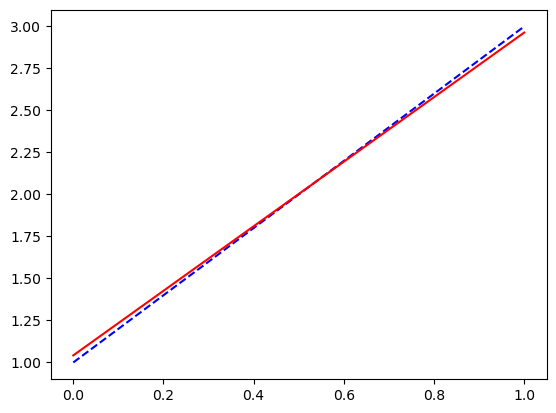

In [16]:
plt.plot(x,y,color='blue',label="True line y=2x+1",linestyle='--')
plt.plot(x,y_pred,color='red',label="prediction")
plt.show()